In [1]:
import torch
print("PyTorch:", torch.__version__)
print("GPU var?", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
GPU var? True
GPU: Tesla T4


In [2]:
import kagglehub

path = kagglehub.dataset_download("puneet6060/intel-image-classification")
print("Data burada:", path)

Using Colab cache for faster access to the 'intel-image-classification' dataset.
Data burada: /kaggle/input/intel-image-classification


In [3]:
import os

train_dir = os.path.join(path, "seg_train", "seg_train")
test_dir  = os.path.join(path, "seg_test", "seg_test")

print("Siniflər və şəkil sayı:\n")
for cls in sorted(os.listdir(train_dir)):
    n_train = len(os.listdir(os.path.join(train_dir, cls)))
    n_test  = len(os.listdir(os.path.join(test_dir, cls)))
    print(f"{cls:10s}  train: {n_train:5d}   test: {n_test:4d}")

Siniflər və şəkil sayı:

buildings   train:  2191   test:  437
forest      train:  2271   test:  474
glacier     train:  2404   test:  553
mountain    train:  2512   test:  525
sea         train:  2274   test:  510
street      train:  2382   test:  501


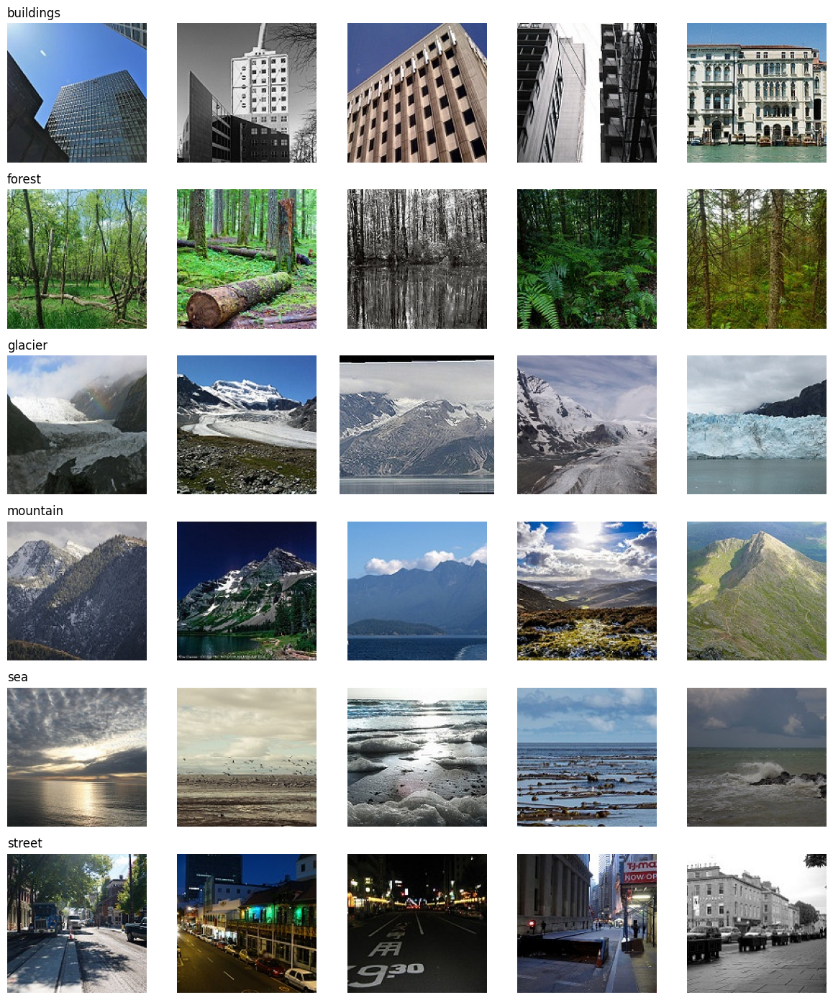

In [4]:
import matplotlib.pyplot as plt
from PIL import Image
import random

classes = sorted(os.listdir(train_dir))
fig, axes = plt.subplots(len(classes), 5, figsize=(12, 14))

for i, cls in enumerate(classes):
    files = random.sample(os.listdir(os.path.join(train_dir, cls)), 5)
    for j, f in enumerate(files):
        img = Image.open(os.path.join(train_dir, cls, f))
        axes[i, j].imshow(img)
        axes[i, j].axis("off")
        if j == 0:
            axes[i, j].set_title(cls, loc="left", fontsize=12)

plt.tight_layout()
plt.show()

In [5]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

IMG_SIZE = 150

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

full_train = datasets.ImageFolder(train_dir, transform=transform)
test_ds    = datasets.ImageFolder(test_dir,  transform=transform)

val_size   = int(0.15 * len(full_train))
train_size = len(full_train) - val_size
generator  = torch.Generator().manual_seed(42)
train_ds, val_ds = random_split(full_train, [train_size, val_size], generator=generator)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False, num_workers=2)

class_names = full_train.classes
print("Siniflər:", class_names)
print(f"Train: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}")

Siniflər: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Train: 11929  Val: 2105  Test: 3000


In [6]:
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),   # 75x75
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),  # 37x37
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2), # 18x18
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

device = "cuda" if torch.cuda.is_available() else "cpu"
model = SimpleCNN(num_classes=len(class_names)).to(device)
print("Parametr sayı:", sum(p.numel() for p in model.parameters()))

Parametr sayı: 390918


In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def run_epoch(model, loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += images.size(0)
    return total_loss / total, correct / total

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
EPOCHS = 10

for epoch in range(EPOCHS):
    tr_loss, tr_acc = run_epoch(model, train_loader, train=True)
    va_loss, va_acc = run_epoch(model, val_loader,   train=False)
    history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc);   history["val_acc"].append(va_acc)
    print(f"Epoch {epoch+1:2d} | train loss {tr_loss:.3f} acc {tr_acc:.3f} | val loss {va_loss:.3f} acc {va_acc:.3f}")

Epoch  1 | train loss 0.854 acc 0.678 | val loss 0.718 acc 0.697
Epoch  2 | train loss 0.633 acc 0.772 | val loss 0.608 acc 0.771
Epoch  3 | train loss 0.561 acc 0.794 | val loss 0.586 acc 0.789
Epoch  4 | train loss 0.531 acc 0.808 | val loss 0.482 acc 0.822
Epoch  5 | train loss 0.507 acc 0.817 | val loss 0.559 acc 0.794
Epoch  6 | train loss 0.471 acc 0.832 | val loss 0.431 acc 0.848
Epoch  7 | train loss 0.452 acc 0.839 | val loss 0.502 acc 0.810
Epoch  8 | train loss 0.424 acc 0.846 | val loss 0.495 acc 0.824
Epoch  9 | train loss 0.409 acc 0.852 | val loss 0.716 acc 0.756
Epoch 10 | train loss 0.404 acc 0.854 | val loss 0.447 acc 0.839


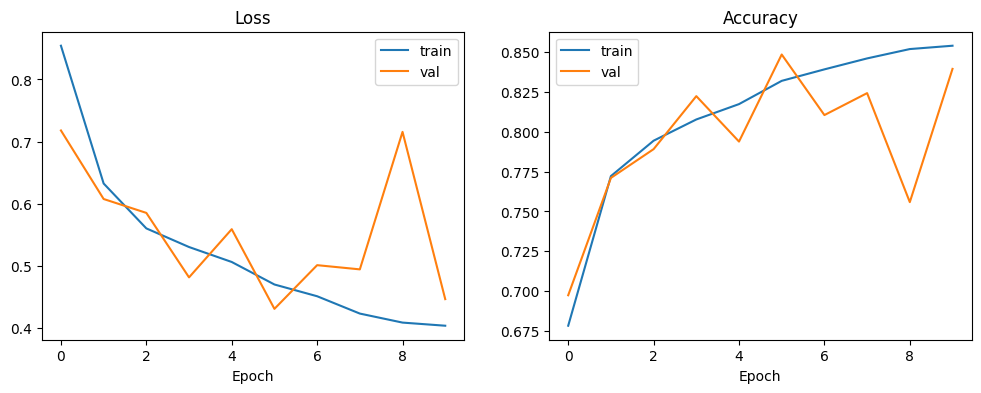

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history["train_loss"], label="train"); ax1.plot(history["val_loss"], label="val")
ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.legend()
ax2.plot(history["train_acc"], label="train"); ax2.plot(history["val_acc"], label="val")
ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch"); ax2.legend()
plt.show()

torch.save(model.state_dict(), "simple_cnn.pth")

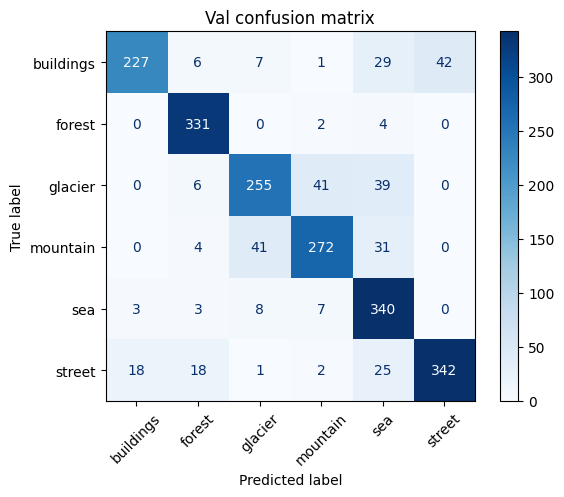

              precision    recall  f1-score   support

   buildings      0.915     0.728     0.811       312
      forest      0.899     0.982     0.939       337
     glacier      0.817     0.748     0.781       341
    mountain      0.837     0.782     0.808       348
         sea      0.726     0.942     0.820       361
      street      0.891     0.842     0.866       406

    accuracy                          0.839      2105
   macro avg      0.848     0.837     0.838      2105
weighted avg      0.847     0.839     0.838      2105



In [9]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        outputs = model(images.to(device))
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds, all_labels = np.array(all_preds), np.array(all_labels)

cm = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(cmap="Blues", xticks_rotation=45)
plt.title("Val confusion matrix")
plt.show()

print(classification_report(all_labels, all_preds, target_names=class_names, digits=3))

Səhv sayı: 338 / 2105


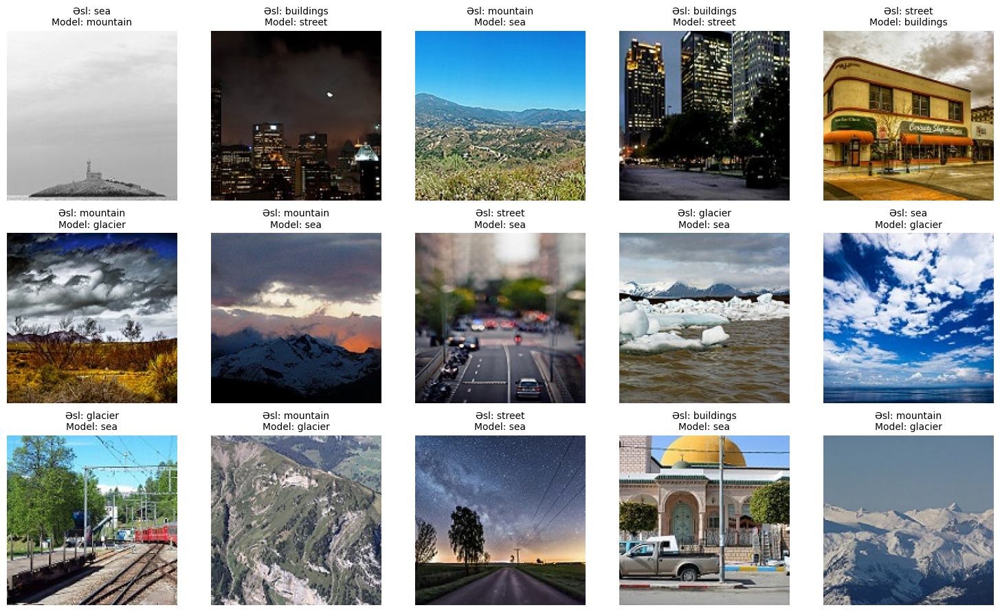

In [10]:
def denorm(t):
    return (t * 0.5 + 0.5).clamp(0, 1).permute(1, 2, 0).numpy()

wrong_idx = np.where(all_preds != all_labels)[0]
print(f"Səhv sayı: {len(wrong_idx)} / {len(all_labels)}")

sample = random.sample(list(wrong_idx), min(15, len(wrong_idx)))
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
for ax, i in zip(axes.flat, sample):
    img, _ = val_ds[i]
    ax.imshow(denorm(img))
    ax.set_title(f"Əsl: {class_names[all_labels[i]]}\nModel: {class_names[all_preds[i]]}", fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [11]:
from torch.utils.data import Subset

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

train_base = datasets.ImageFolder(train_dir, transform=train_transform)
val_base   = datasets.ImageFolder(train_dir, transform=transform)

train_ds_aug = Subset(train_base, train_ds.indices)
val_ds_same  = Subset(val_base,   val_ds.indices)

train_loader = DataLoader(train_ds_aug, batch_size=64, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds_same,  batch_size=64, shuffle=False, num_workers=2)

In [12]:
import copy

model = SimpleCNN(num_classes=len(class_names)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 20
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

history2 = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_acc, best_state, best_epoch = 0.0, None, 0

for epoch in range(EPOCHS):
    tr_loss, tr_acc = run_epoch(model, train_loader, train=True)
    va_loss, va_acc = run_epoch(model, val_loader,   train=False)
    scheduler.step()

    history2["train_loss"].append(tr_loss); history2["val_loss"].append(va_loss)
    history2["train_acc"].append(tr_acc);   history2["val_acc"].append(va_acc)

    mark = ""
    if va_acc > best_acc:
        best_acc, best_epoch = va_acc, epoch + 1
        best_state = copy.deepcopy(model.state_dict())
        mark = "  ← ən yaxşı"
    lr = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch+1:2d} | lr {lr:.5f} | train acc {tr_acc:.3f} | val loss {va_loss:.3f} acc {va_acc:.3f}{mark}")

model.load_state_dict(best_state)
torch.save(best_state, "simple_cnn_aug_best.pth")
print(f"\nƏn yaxşı val accuracy: {best_acc:.3f} (epoch {best_epoch})")

Epoch  1 | lr 0.00099 | train acc 0.649 | val loss 0.829 acc 0.678  ← ən yaxşı
Epoch  2 | lr 0.00098 | train acc 0.744 | val loss 0.950 acc 0.603
Epoch  3 | lr 0.00095 | train acc 0.766 | val loss 0.554 acc 0.806  ← ən yaxşı
Epoch  4 | lr 0.00090 | train acc 0.788 | val loss 0.714 acc 0.720
Epoch  5 | lr 0.00085 | train acc 0.800 | val loss 0.717 acc 0.748
Epoch  6 | lr 0.00079 | train acc 0.809 | val loss 0.496 acc 0.824  ← ən yaxşı
Epoch  7 | lr 0.00073 | train acc 0.818 | val loss 0.473 acc 0.823
Epoch  8 | lr 0.00065 | train acc 0.825 | val loss 0.544 acc 0.803
Epoch  9 | lr 0.00058 | train acc 0.831 | val loss 0.605 acc 0.765
Epoch 10 | lr 0.00050 | train acc 0.846 | val loss 0.455 acc 0.837  ← ən yaxşı
Epoch 11 | lr 0.00042 | train acc 0.851 | val loss 0.529 acc 0.805
Epoch 12 | lr 0.00035 | train acc 0.855 | val loss 0.387 acc 0.857  ← ən yaxşı
Epoch 13 | lr 0.00027 | train acc 0.865 | val loss 0.396 acc 0.861  ← ən yaxşı
Epoch 14 | lr 0.00021 | train acc 0.871 | val loss 0.479 

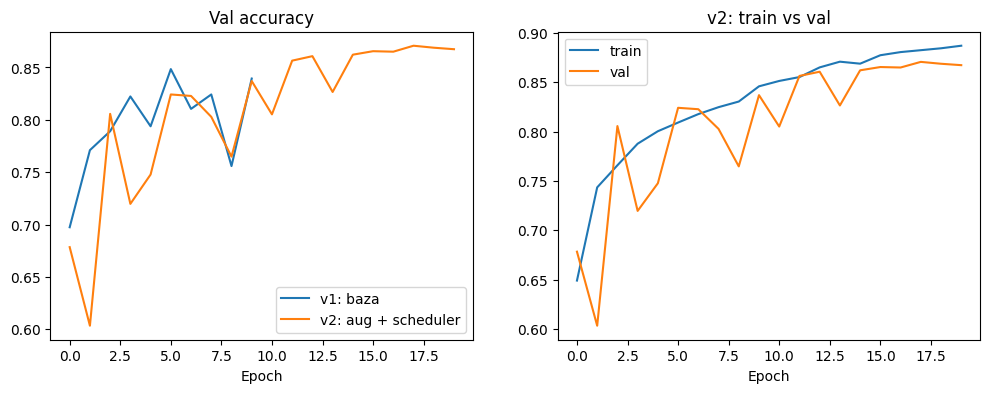

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history["val_acc"],  label="v1: baza")
ax1.plot(history2["val_acc"], label="v2: aug + scheduler")
ax1.set_title("Val accuracy"); ax1.set_xlabel("Epoch"); ax1.legend()
ax2.plot(history2["train_acc"], label="train")
ax2.plot(history2["val_acc"],   label="val")
ax2.set_title("v2: train vs val"); ax2.set_xlabel("Epoch"); ax2.legend()
plt.show()

In [14]:
from torchvision import models

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
TL_SIZE = 224

tl_train_tf = transforms.Compose([
    transforms.RandomResizedCrop(TL_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
tl_eval_tf = transforms.Compose([
    transforms.Resize((TL_SIZE, TL_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

tl_train_ds = Subset(datasets.ImageFolder(train_dir, transform=tl_train_tf), train_ds.indices)
tl_val_ds   = Subset(datasets.ImageFolder(train_dir, transform=tl_eval_tf),  val_ds.indices)

tl_train_loader = DataLoader(tl_train_ds, batch_size=64, shuffle=True,  num_workers=2)
tl_val_loader   = DataLoader(tl_val_ds,   batch_size=64, shuffle=False, num_workers=2)

tl_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
tl_model.fc = nn.Linear(tl_model.fc.in_features, len(class_names))   # 1000 sinif → 6 sinif
tl_model = tl_model.to(device)

print("Parametr sayı:", sum(p.numel() for p in tl_model.parameters()))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 186MB/s]


Parametr sayı: 11179590


In [15]:
model = tl_model
optimizer = torch.optim.AdamW(tl_model.parameters(), lr=1e-4, weight_decay=1e-4)

EPOCHS = 6
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

history3 = {"train_acc": [], "val_acc": []}
best_acc, best_state, best_epoch = 0.0, None, 0

for epoch in range(EPOCHS):
    tr_loss, tr_acc = run_epoch(tl_model, tl_train_loader, train=True)
    va_loss, va_acc = run_epoch(tl_model, tl_val_loader,   train=False)
    scheduler.step()
    history3["train_acc"].append(tr_acc); history3["val_acc"].append(va_acc)

    mark = ""
    if va_acc > best_acc:
        best_acc, best_epoch = va_acc, epoch + 1
        best_state = copy.deepcopy(tl_model.state_dict())
        mark = "  ← ən yaxşı"
    print(f"Epoch {epoch+1} | train acc {tr_acc:.3f} | val loss {va_loss:.3f} acc {va_acc:.3f}{mark}")

tl_model.load_state_dict(best_state)
torch.save(best_state, "resnet18_best.pth")
print(f"\nƏn yaxşı val accuracy: {best_acc:.3f} (epoch {best_epoch})")

Epoch 1 | train acc 0.897 | val loss 0.232 acc 0.924  ← ən yaxşı
Epoch 2 | train acc 0.936 | val loss 0.188 acc 0.933  ← ən yaxşı
Epoch 3 | train acc 0.954 | val loss 0.171 acc 0.941  ← ən yaxşı
Epoch 4 | train acc 0.969 | val loss 0.181 acc 0.938
Epoch 5 | train acc 0.978 | val loss 0.171 acc 0.945  ← ən yaxşı
Epoch 6 | train acc 0.986 | val loss 0.167 acc 0.951  ← ən yaxşı

Ən yaxşı val accuracy: 0.951 (epoch 6)


In [16]:
def evaluate(model, loader):
    model.eval()
    preds, labels_all = [], []
    with torch.no_grad():
        for images, labels in loader:
            preds.extend(model(images.to(device)).argmax(1).cpu().numpy())
            labels_all.extend(labels.numpy())
    preds, labels_all = np.array(preds), np.array(labels_all)
    return (preds == labels_all).mean(), preds, labels_all

# Kiçik CNN-lər üçün test (150x150, 0.5 normalize)
cnn_v1 = SimpleCNN(len(class_names)).to(device)
cnn_v1.load_state_dict(torch.load("simple_cnn.pth"))
cnn_v2 = SimpleCNN(len(class_names)).to(device)
cnn_v2.load_state_dict(torch.load("simple_cnn_aug_best.pth"))

# ResNet üçün test (224x224, ImageNet normalize)
tl_test_ds = datasets.ImageFolder(test_dir, transform=tl_eval_tf)
tl_test_loader = DataLoader(tl_test_ds, batch_size=64, shuffle=False, num_workers=2)

acc_v1, _, _ = evaluate(cnn_v1, test_loader)
acc_v2, _, _ = evaluate(cnn_v2, test_loader)
acc_tl, tl_preds, tl_labels = evaluate(tl_model, tl_test_loader)

print("| Model | Parametr | Epoch | Test accuracy |")
print("|---|---|---|---|")
print(f"| v1: Sadə CNN | {sum(p.numel() for p in cnn_v1.parameters()):,} | 10 | {acc_v1:.3f} |")
print(f"| v2: CNN + aug + scheduler | {sum(p.numel() for p in cnn_v2.parameters()):,} | 20 | {acc_v2:.3f} |")
print(f"| v3: ResNet18 transfer learning | {sum(p.numel() for p in tl_model.parameters()):,} | 6 | {acc_tl:.3f} |")

| Model | Parametr | Epoch | Test accuracy |
|---|---|---|---|
| v1: Sadə CNN | 390,918 | 10 | 0.843 |
| v2: CNN + aug + scheduler | 390,918 | 20 | 0.885 |
| v3: ResNet18 transfer learning | 11,179,590 | 6 | 0.942 |


              precision    recall  f1-score   support

   buildings      0.928     0.941     0.934       437
      forest      0.994     0.998     0.996       474
     glacier      0.921     0.882     0.901       553
    mountain      0.906     0.914     0.910       525
         sea      0.962     0.986     0.974       510
      street      0.948     0.942     0.945       501

    accuracy                          0.942      3000
   macro avg      0.943     0.944     0.943      3000
weighted avg      0.942     0.942     0.942      3000



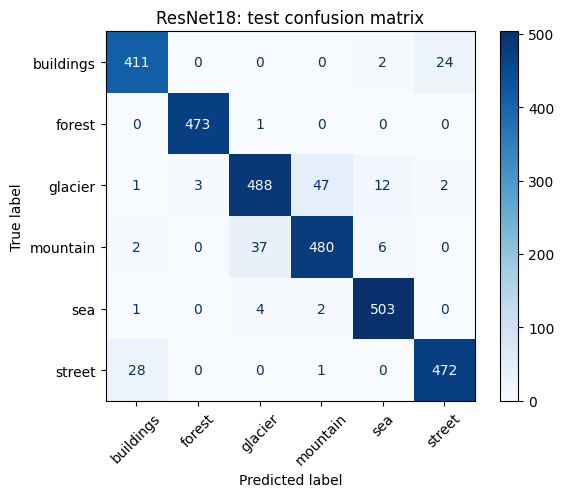

In [17]:
print(classification_report(tl_labels, tl_preds, target_names=class_names, digits=3))

cm = confusion_matrix(tl_labels, tl_preds)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(cmap="Blues", xticks_rotation=45)
plt.title("ResNet18: test confusion matrix")
plt.savefig("confusion_matrix_test.png", dpi=150, bbox_inches="tight")
plt.show()

In [18]:
!pip install -q grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 3.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


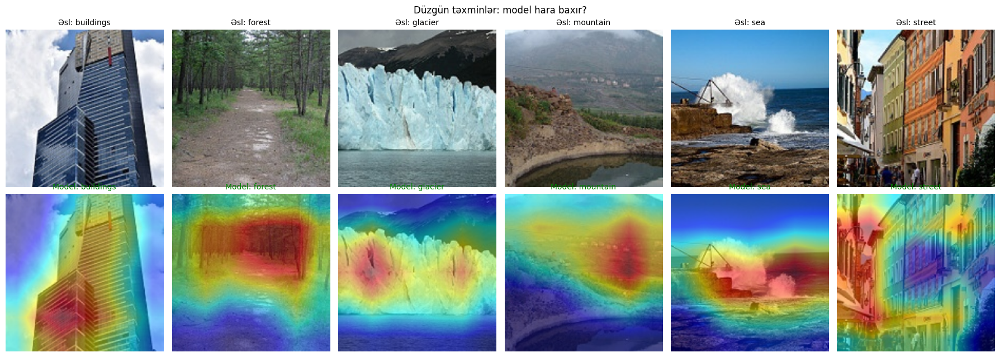

Səhv sayı: 173 / 3000


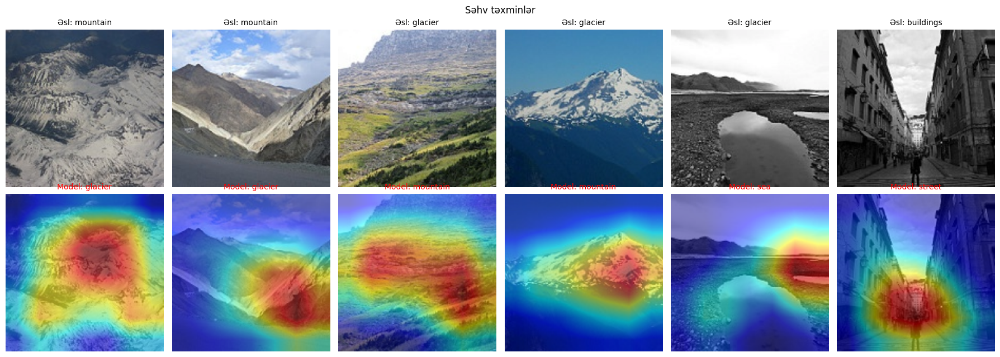

In [19]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

cam = GradCAM(model=tl_model, target_layers=[tl_model.layer4[-1]])  # ResNet-in son conv bloku

def denorm_imagenet(t):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (t * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

def show_gradcam(indices, title):
    fig, axes = plt.subplots(2, len(indices), figsize=(3 * len(indices), 6.5))
    for col, i in enumerate(indices):
        img_t, label = tl_test_ds[i]
        pred = tl_preds[i]
        heat = cam(input_tensor=img_t.unsqueeze(0).to(device),
                   targets=[ClassifierOutputTarget(pred)])[0]
        rgb = denorm_imagenet(img_t)
        axes[0, col].imshow(rgb); axes[0, col].axis("off")
        axes[0, col].set_title(f"Əsl: {class_names[label]}", fontsize=10)
        axes[1, col].imshow(show_cam_on_image(rgb, heat, use_rgb=True)); axes[1, col].axis("off")
        axes[1, col].set_title(f"Model: {class_names[pred]}", fontsize=10,
                               color="green" if pred == label else "red")
    plt.suptitle(title); plt.tight_layout(); plt.show()

# Düzgün təxminlər: hər sinifdən bir
correct = [np.where((tl_labels == c) & (tl_preds == c))[0][0] for c in range(len(class_names))]
show_gradcam(correct, "Düzgün təxminlər: model hara baxır?")

# Səhv təxminlər
wrong = np.where(tl_preds != tl_labels)[0]
print(f"Səhv sayı: {len(wrong)} / {len(tl_labels)}")
show_gradcam(random.sample(list(wrong), min(6, len(wrong))), "Səhv təxminlər")

In [20]:
from collections import Counter

pairs = Counter()
for t, p in zip(tl_labels, tl_preds):
    if t != p:
        a, b = sorted([class_names[t], class_names[p]])
        pairs[f"{a} ↔ {b}"] += 1

print("Ən çox qarışan cütlər:\n")
for pair, n in pairs.most_common(6):
    print(f"{pair:25s} {n:3d}  ({n / len(wrong) * 100:.0f}% səhvlərin)")

Ən çox qarışan cütlər:

glacier ↔ mountain         84  (49% səhvlərin)
buildings ↔ street         52  (30% səhvlərin)
glacier ↔ sea              16  (9% səhvlərin)
mountain ↔ sea              8  (5% səhvlərin)
forest ↔ glacier            4  (2% səhvlərin)
buildings ↔ sea             3  (2% səhvlərin)


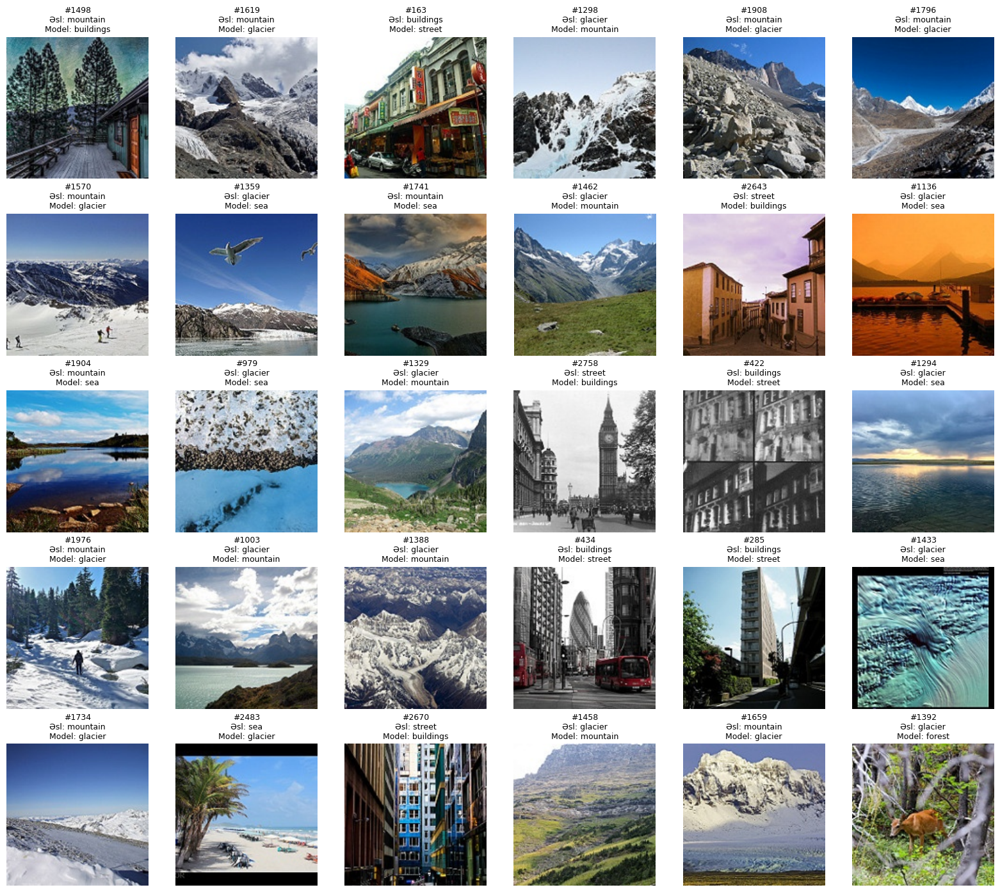

In [21]:
sample30 = random.Random(0).sample(list(wrong), 30)
fig, axes = plt.subplots(5, 6, figsize=(16, 14))
for ax, i in zip(axes.flat, sample30):
    img_t, label = tl_test_ds[i]
    ax.imshow(denorm_imagenet(img_t)); ax.axis("off")
    ax.set_title(f"#{i}\nƏsl: {class_names[label]}\nModel: {class_names[tl_preds[i]]}", fontsize=9)
plt.tight_layout(); plt.show()